<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [2]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/02_ML
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

<IPython.core.display.Latex object>

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/02_ML/images/slide4.png" width="60%"/>
</center>

# Instance-based classification

## Learning task (1)
Our neighbor likes flowers and has lots of them in her garden. Sometimes she forgets how to distinguish different species and then you have to search the Web for descriptions. This is quite tedious and takes lots of time. Therefore you decided to automate this process.

- **Task**: differentiate between flowers
- **Performance measure**: the accuracy of classification must be maximized - ratio of the number of correct answers to the number of incorrect ones.

## Learning task (2)

- When $T$ and $P$ are defined you start the analysis of the environment to define the training experience 

- Possibilities: flower beds are labeled - labeled data is available
    + make photos of flowers
    + measure some flower parameters: petal/sepal length/width
    + use you new electronic odometer to record smells
    + all together or some subset of the above

## Data acquisition 

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/02_ML/images/slide8.png" width="50%"/>
</center>

- **Training experience**: measurements of petal/sepal length/width
    + not so much data as for photos (different perspectives)
    + easy to measure comparing to the electronic odometer

- **Assumptions**: simplifications of the real-world
    + the noise in measurements or flower seeds is negligible
    + we take 50 samples of every specie and assume that are they representative

## Formal representation

- Features (attributes, dimensions)

\begin{equation*}
\vec{X}=
\begin{bmatrix}
    sl_{11} & sw_{12} & pl_{13} & pw_{14} \\
    sl_{21} & sw_{22} & pl_{23} & pw_{24} \\
    \vdots & \vdots & \vdots & \vdots \\
    sl_{n1} & sw_{n2} & pl_{n3} & pw_{n4}
\end{bmatrix}
\end{equation*}

- Classes (targets)

\begin{equation*}
\vec{y} = 
\begin{bmatrix}
    y_{1} & y_{2} & \dots & y_{n}
\end{bmatrix}
\end{equation*}


In [3]:
# load the dataset
iris = sns.load_dataset("iris")
# get 5 first samples from the dataset
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
def f(x) : return iris.loc[iris.species==x].describe()
interact(f, x=['setosa','versicolor','virginica']);

interactive(children=(Dropdown(description='x', options=('setosa', 'versicolor', 'virginica'), value='setosa')…

In [5]:
@interact(specie=['none','setosa','virginica','versicolor'])
def plt_stats(specie='none'):
    t = iris if specie=='none' else iris.loc[iris.species==specie]
    sns.boxplot(data=t)
    plt.show()

interactive(children=(Dropdown(description='specie', options=('none', 'setosa', 'virginica', 'versicolor'), va…

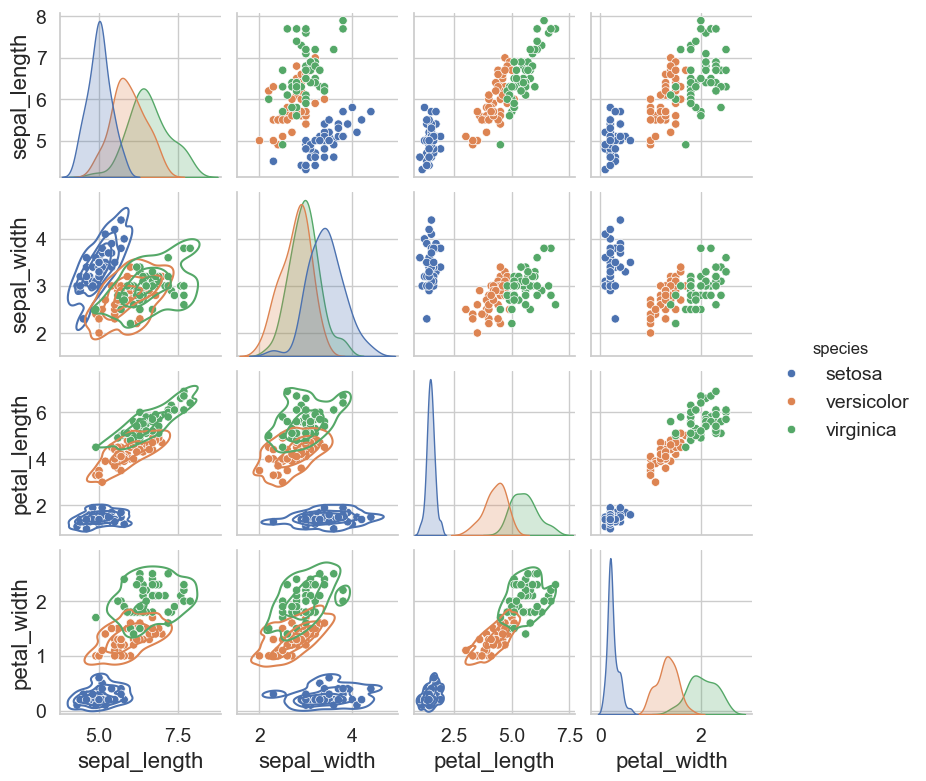

In [6]:
fig = sns.pairplot(iris, hue="species", height=2)
fig.map_lower(sns.kdeplot, levels=4, color=".2");

## Correlation

- *Correlation* is a statistical relationship between two random variables
- *Pearson Correlation* coefficient $r$ for a sample: indicates strength and direction of the linear relationship between two continuous normally distributed variables $\rvar{x}$ and $\rvar{y}$
$$r_{\rvar{x}\rvar{y}}={\frac {\sum _{i=1}^{n}(x_{i}-{\bar {x}})(y_{i}-{\bar {y}})}{{\sqrt {\sum _{i=1}^{n}(x_{i}-{\bar {x}})^{2}}}{\sqrt {\sum _{i=1}^{n}(y_{i}-{\bar {y}})^{2}}}}}$$

- Correlation is very important for methods that assume the *form* of the relationship
    - For instance, linear regression assumes a linear function as a model
- Correlation is focused on the *strength* of a relationship
- Non-linear relations: *Spearman correlation* assesses how well the relationship between two variables can be described using a monotonic function

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


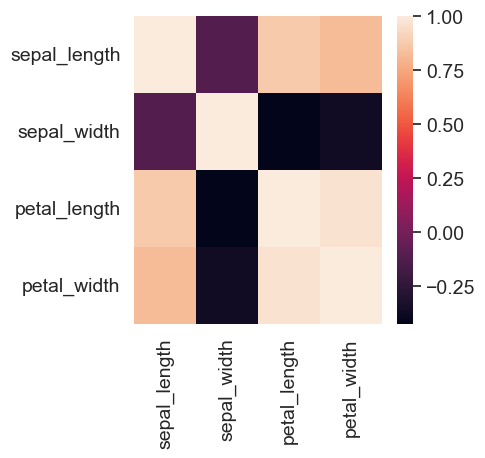

In [7]:
t = iris.iloc[:,0:4].corr()
plt.figure(figsize=(4,4))
print(t)
sns.heatmap(t);

### Significance of a correlation coefficient

- Since we determine the coefficient using only a sample of all possible observations, we are interested if the obtained value is statistically significant
    - $H_0$: we got the value due to a "lucky" sample, therefore it is insignificant and can be set to 0
    - $H_1$: the correlation coefficient is significant
- *p-value* - provides an evidence against the $H_0$ hypothesis

- Technically, hypothesis testing looks as follows: 
    + Select a the significance level $\alpha$, usually $\alpha=.05$
    + $p_{value} \leq \alpha$ the $r$ value is statistically significant
      - For example, a p-value of 0.025 is a 2.5% chance that the value happened by chance and 
      - Since $0.025 < 0.05$ we assume that this chance is neglectable and $H_0$ can be rejected
    + t-Test for correlation: 
        - Compute $\mathit{p_{value}} = 2\cdot P(T>t)$ where $T$ follows Student distribution with $n-2$ degrees of freedom and $n$ is the number of observations
    $$ t = r \sqrt{\frac{n-2}{1-r^2}} $$
        + If $\mathit{p_{value}}\leq\alpha$, then accept $r$ value.
        + Otherwise, we can cannot conclude that $r$ is different from $0$

## Algorithm idea
- **Goal**: given a feature vector $\vec{c}$ of real-valued measurements, assign it a label from one of the three classes
    + *distance*: the same label as of the nearest observation $\vec{x}$ with respect to some distance, e.g.,  Euclidean, Manhattan,  Chebyshev, or Minkowsky, between known feature vector $\vec{x}^{(i)}$ and a new one $\vec{c}$.
    Example for the Minkowsky distance, which is a generalization of other distances named above:
    \begin{equation*}
      \vec{x} = \text{argmin}_{\vec{x}^{(i)}} \left(
          \sum_k{
            \lvert x^{(i)}_k - c_k \rvert^p}\right)^\frac{1}{p}
    \end{equation*}   
    + *k Nearest Neighbors (kNN)*: consider multiple distances from $k$ nearest observations and make a voting
- **Selection**: we go for kNN since the classes appear to be well-separable given available observations 

In [8]:
def approx(show=False):
    plt.figure(figsize=(10,10))
    ax = sns.scatterplot(x=iris.sepal_length, y=iris.petal_length, hue=iris.species)
    ax.set_xlim(0,8)
    ax.set_ylim(0,8)
    
    if show==False: return
    # a new unclassified observation
    plt.scatter(x=5.5, y=4.7, color='m')

    # radius simulates kNN with k=5 and Euclidian distance
    ax.add_artist(plt.Circle((5.5, 4.7), radius=0.3, color='m', alpha=0.3))
    plt.show()

interactive(children=(ToggleButton(value=False, description='show'), Output()), _dom_classes=('widget-interact…

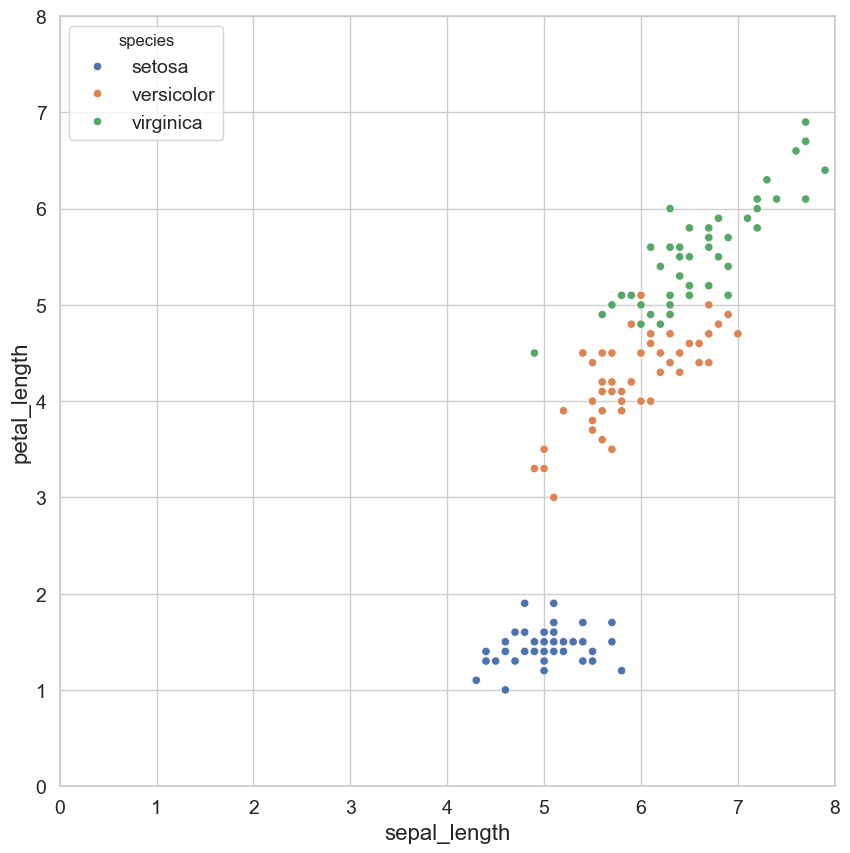

In [9]:
interact(approx, show=widgets.ToggleButton(value=False));

## kNN algorithm

- **Representation**: since distances are computed from known feature vectors, we represent our knowledge by a pair $\langle\vec{X},\vec{y}\rangle$

- **kNN Learning algorithm**:
    + evaluate distance from every $\vec{x}^{(i)}$ to $\vec{c}$
    + select $k$ nearest points
    + assign a label of the majority
    + use lexicographically smallest label as a tie breaker

## Train-test split

- The data set is balanced with 50 samples per class, but quite small
- We need data to test the ability of the classification model to generalize beyond the training data
- The split available data into two data sets for training and testing
- Consider 3 variants: 
    - Simply get the first $n$ records
    - Select $n$ records at random
    - Select $n$ random records such that proportions of classes are preserved - *stratified sampling*

Text(0.5, 1.0, 'Random sampling')

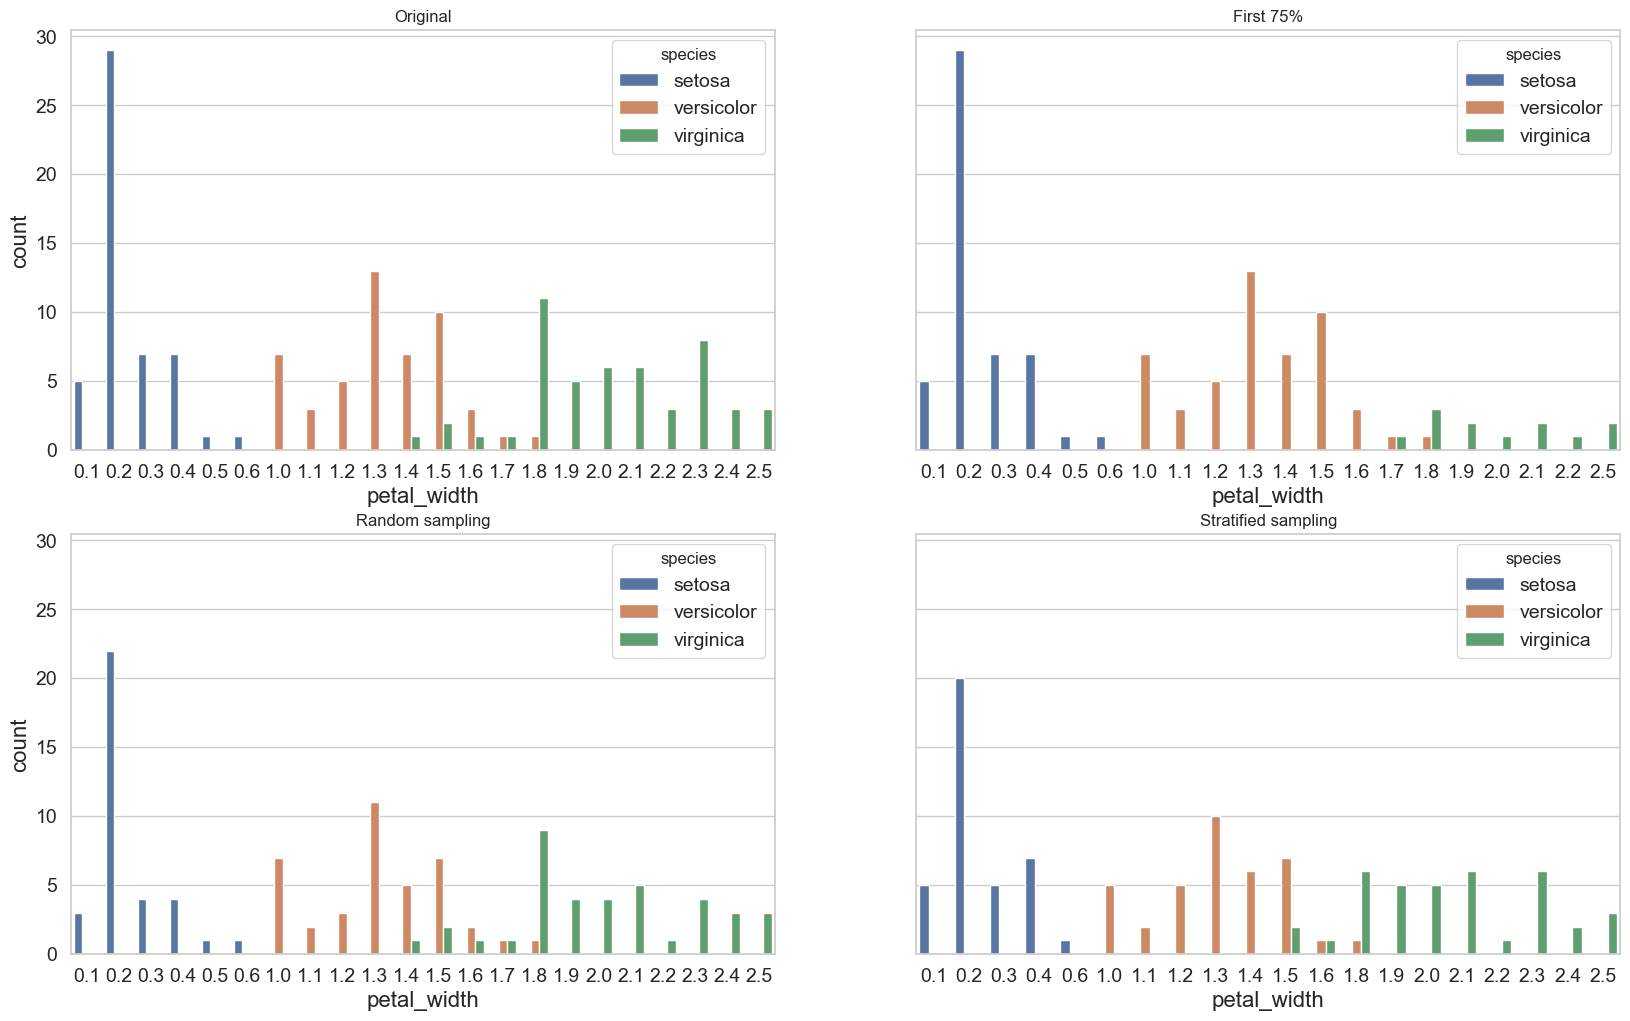

In [10]:
import sklearn.model_selection as sel

# select first 75% of all observations as training set
iris_1 = iris.head(round(len(iris.index)*0.75))
# stratified sampling - same number of observations are selected randomly per class
iris_2 = sel.train_test_split(iris, test_size=0.25, random_state=42, stratify=iris.species)
# random sampling
iris_3 = sel.train_test_split(iris, test_size=0.25, random_state=42)

fig, ax = plt.subplots(2,2, sharey=True, figsize=(20,12))
sns.countplot(x="petal_width", data=iris, hue="species", ax=ax[0,0]).set_title("Original")
sns.countplot(x="petal_width", data=iris_1, hue="species", ax=ax[0,1]).set_title("First 75%")
sns.countplot(x="petal_width", data=iris_2[0].sort_index(), hue="species", ax=ax[1,1]).set_title("Stratified sampling")
sns.countplot(x="petal_width", data=iris_3[0].sort_index(), hue="species", ax=ax[1,0]).set_title("Random sampling")

## Implementing in Python

- **Home work**: try to find the best value of the hyperparamenter $k$ using k-fold Cross Validation with Grid or Randomized search
- Before running the experiments:
  - Fix your random state before the experiment, e.g., by assigning it some random value
  - Decide if you want to use stratified version of the k-fold CV procedure

In [11]:
def split_data(data, stratify=None, test_size=0.25, random_state=7):
    s = sel.train_test_split(data, test_size=test_size, random_state=random_state, stratify=stratify)
    
    train_y = s[0].pop("species").values
    train_X = s[0].values
    test_y = s[1].pop("species").values
    test_X = s[1].values
    
    return train_X, train_y, test_X, test_y

def plot(classifier, train_X, train_y, test_X, test_y):
      
    pred_y = classifier.predict(test_X)
    fig, axs = plt.subplots(1,2, figsize=(15,9))

    print("Accuracy:", np.sum(pred_y == test_y) / float(len(test_y)))
    print('Correctly classified:', np.where(pred_y == test_y)[0])
    print('Samples incorrectly classified:', np.where(pred_y != test_y)[0])
    sns.heatmap(metrics.confusion_matrix(test_y, pred_y), 
                cmap="Blues", annot=True, ax=axs[0], annot_kws={"size": 16})
    
    colors = ["darkblue", "green", "red"]
    data_markers=["s","s","s"]
    markers= ["x","D","o"]

    target_names = iris.species.unique()

    d1,d2 = 3,0

    for n, color in enumerate(colors):
        t_idx = np.where(train_y == target_names[n])[0]
        sns.scatterplot(x=train_X.iloc[t_idx,d1], y=train_X.iloc[t_idx,d2], color=color, 
                        label="Train: %s" % target_names[n], marker=data_markers[n], ax=axs[1], s=48)

    for n, color in enumerate(colors):
        for k, marker in enumerate(markers):
            inc_idx = np.where((pred_y != test_y) & (test_y == target_names[n]) & (pred_y == target_names[k]))[0]
            if len(inc_idx)>0:
                sns.scatterplot(x=test_X.iloc[inc_idx, d1], y=test_X.iloc[inc_idx, d2], marker=marker, color=color,
                   label="Fault: %s" % target_names[k], ax=axs[1], s=64)

    print('Colors indicate correct classes and markers an error')
    plt.xlabel(iris.columns[d1])
    plt.ylabel(iris.columns[d2])
    plt.legend(loc='upper left')
    plt.title("Iris Classification results")
    plt.show()

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def kNN(k=8, test_size=0.25, random_state=7, stratify=0):
    st = None
    if stratify > 0: 
        st = iris.species

    train_X, train_y, test_X, test_y = split_data(iris, st)

    classifier = KNeighborsClassifier(n_neighbors=k)

    classifier.fit(train_X, train_y)
    plot(classifier, train_X, train_y, test_X, test_y)

interactive(children=(IntSlider(value=8, description='k', max=9, min=2), FloatSlider(value=0.25, description='…

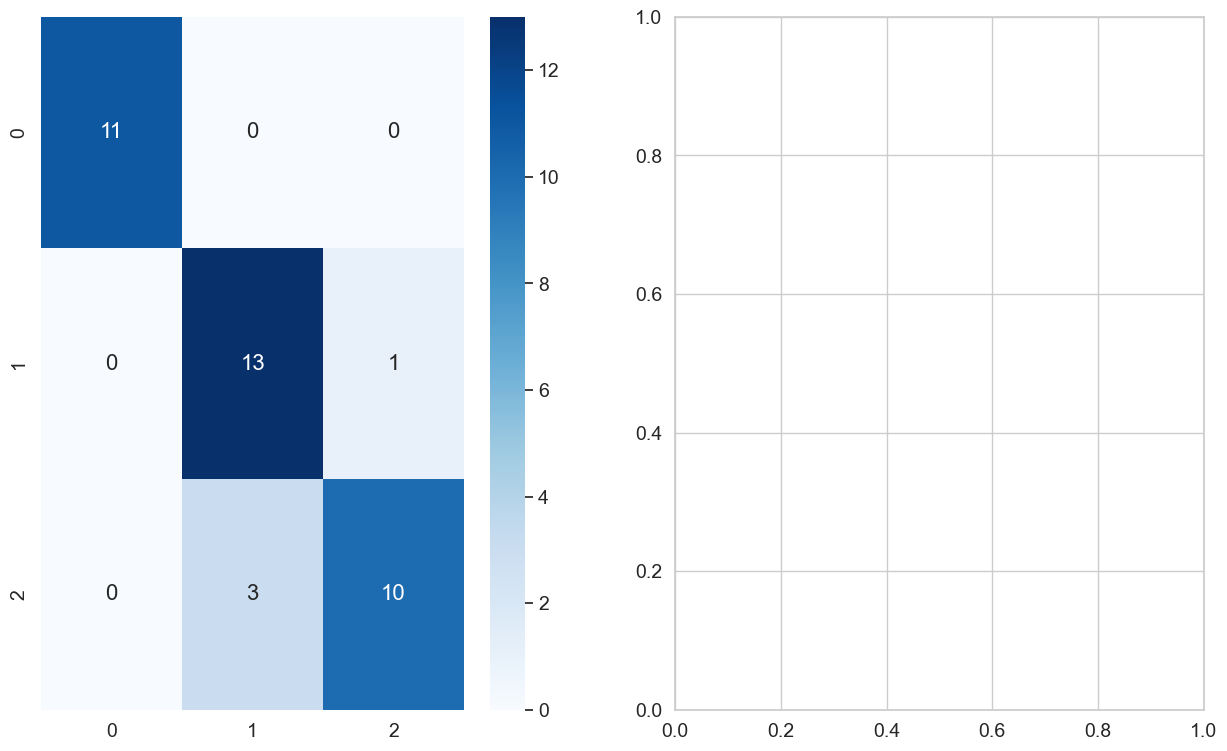

In [13]:
interact(kNN, k=(2,9,1), test_size=(0.1,0.9,0.15), random_state=(3,11,1), stratify=(0, 1, 1));

## Homework: Hyperparameter optimization

- Finding of the best hyperparameters manually is tedious:
    - Which $k=\{3,\dots,n\}$ is the best?
    - Can we avoid the influence of a train-test split choice?
- *How can we find the best set of parameters for the iris classification problem?*

### Answer: Hyperparameter optimization + cross validation

- Possible implementation - `GridSearchCV` in the `sklearn` package
    - GridSearch - brute force optimization method
    - CV - Cross-fold Validation

In [14]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors' : range(3,10)}
knn = KNeighborsClassifier()

# use 5-fold CV with F1 (macro - average over all tests) 
# to select the best k
gscv = GridSearchCV(knn, parameters, scoring='f1_macro', cv=5, verbose=3)
data = iris.iloc[:, range(0,4)]
target = iris['species']
gscv.fit(data, target);

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .....................n_neighbors=3;, score=0.967 total time=   0.0s
[CV 2/5] END .....................n_neighbors=3;, score=0.967 total time=   0.0s
[CV 3/5] END .....................n_neighbors=3;, score=0.933 total time=   0.0s
[CV 4/5] END .....................n_neighbors=3;, score=0.967 total time=   0.0s
[CV 5/5] END .....................n_neighbors=3;, score=1.000 total time=   0.0s
[CV 1/5] END .....................n_neighbors=4;, score=0.967 total time=   0.0s
[CV 2/5] END .....................n_neighbors=4;, score=0.967 total time=   0.0s
[CV 3/5] END .....................n_neighbors=4;, score=0.967 total time=   0.0s
[CV 4/5] END .....................n_neighbors=4;, score=0.967 total time=   0.0s
[CV 5/5] END .....................n_neighbors=4;, score=1.000 total time=   0.0s
[CV 1/5] END .....................n_neighbors=5;, score=0.967 total time=   0.0s
[CV 2/5] END .....................n_neighbors=5;,

In [15]:
cvr = pd.DataFrame(gscv.cv_results_)
cvr[['param_n_neighbors','mean_fit_time','mean_test_score',
     'std_test_score','rank_test_score']]

,param_n_neighbors,mean_fit_time,mean_test_score,std_test_score,rank_test_score
0,3,0.000864,0.966482,0.021295,7
1,4,0.000695,0.973266,0.013367,4
2,5,0.000628,0.973165,0.025170,5
3,6,0.000625,0.979950,0.016371,1
4,7,0.000620,0.979950,0.016371,1
5,8,0.000623,0.966650,0.029814,6
6,9,0.000616,0.973300,0.024953,3


## Implementing with Weights and Biases

In [23]:
import wandb
from sklearn.metrics import accuracy_score

# your credentials must already be provided to wandb, e.g., by calling 'wandb login' in the terminal
wandb.login()

def kNN_wandb(k, train_X, train_y, test_X, test_y):
    with wandb.init(entity="aau-ai-ml", project="ai-ml", config={"model": "kNN", "k": k}) as run:

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_X, train_y)
        pred = knn.predict(test_X)
        probas = knn.predict_proba(test_X)

        accuracy = accuracy_score(test_y, pred)
        run.log({"accuracy": accuracy})
        run.summary["accuracy"] = accuracy

        wandb.sklearn.plot_classifier(knn, train_X, test_X, train_y, test_y, pred, probas, ['setosa', 'virginica', 'versicolor'], is_binary=False, model_name='kNN')

    wandb.finish()

In [24]:
train_X, train_y, test_X, test_y = split_data(iris, iris.species, test_size=0.25, random_state=57)
kNN_wandb(3, train_X, train_y, test_X, test_y)

wandb: 
wandb: Plotting kNN.
wandb: WARNING could not find any of attributes feature_importances_, feature_log_prob_, coef_ on classifier. Cannot plot feature importances.
wandb: Logged feature importances.
wandb: Logged confusion matrix.
wandb: Logged summary metrics.
wandb: Logged class proportions.
wandb: WARNING This function only supports binary classification at the moment and therefore expects labels to be binary. Skipping calibration curve.
wandb: Logged calibration curve.
wandb: Logged roc curve.
wandb: Logged precision-recall curve.


accuracy,▁
accuracy,0.97368


In [25]:
sweep_configuration = {
    'method': 'grid',
    'name': 'Grid Search kNN',
    'metric': {
        'goal': 'maximize',
        'name': 'f1',
    },
    'parameters': {
        'n_neighbors': {
            'values': [3, 5, 7, 8, 9]
        },
        'random_state': {
            'values': [3, 5, 7, 9, 11, 42]
        }
    }
}

sweep_id = wandb.sweep(sweep_configuration, project="ai-ml", entity="aau-ai-ml")

def sweep_train(config=None):
    with wandb.init(entity="aau-ai-ml", project="ai-ml", config=config) as run:
        train_X, train_y, test_X, test_y = split_data(iris, iris.species, test_size=0.25, random_state=run.config.random_state)
        k = run.config.n_neighbors
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_X, train_y)
        pred = knn.predict(test_X)
        f1 = metrics.f1_score(test_y, pred, average='macro')
        accuracy = accuracy_score(test_y, pred)
        run.log({"accuracy": accuracy})
        run.log({"f1": f1})
 

Create sweep with ID: lgd7dt30
Sweep URL: https://wandb.ai/aau-ai-ml/ai-ml/sweeps/lgd7dt30
